# Utilisation de `pyannote.audio` dans le cadre du projet `phles-nid`

Ce tutoriel décrit comment utiliser `pyannote.audio` dans le but:
- d'entraîner et de valider des modèles sur une tâche de segmentation d'événements de déglutition, de phonation ou encore de toux.
- d'évaluer les systèmes ainsi obtenus sur cette même tâche.


# Installation

Cette première partie décrit les étapes à suivre pour préparer l'environnement du tutoriel. Celui-ci nécessite d'installer une version particulière de `pyannote.audio` disposant de l'intégralité des modifications apportées à cette librairie dans le cadre du projet `phles-nid`. Cette version (branche git) est accessible [ici](https://github.com/clement-pages/pyannote-audio/tree/phlesnid). Cette version de `pyannote.audio` est également disponible dans `projects/phlesnid/clement/pyannote-audio` (s'assurer que le répertoire est sur la branche `phlesnid` en faisant un `git status`).

Il est recommandé d'installer `pyannote.audio` dans un environnement virtuel. La mise en place d'un tel environnement peut-être réalisée en suivant les instructions fournies dans la [documentation d'Occidata](https://occidata.irit.fr/docs/slurm/gpu/). Une fois l'environnement activé, il est possible d'installer `pyannote.audio` à l'aide d'une des commandes suivantes:

- Installation de la version de `pyannote.audio` contenant les modifications pour `phles-nid`, ainsi que des dépendances nécessaires au fonctionnement de `pyannote` (depuis le répertoire github) :

````bash
pip install git+https://github.com/clement-pages/pyannote-audio.git@phlesnid
````

- Installation de `pyannote.audio` à partir du répertoire local sur Occidata, avec l'option "-e" qui permet d'éditer le package et de répercuter automatiquement les modifications dans l'environnement :

````bash
cd /projects/phlesnid/clement/pyannote-audio # remplacer par votre version de pyannote-audio
pip install -e .
````

La dernière étape consiste à créer un kernel pour pouvoir utiliser l'environnement dans un notebook. Cela est fait à l'aide de cette commande (l'environnement doit être activé):

```bash
pip install ipykernel
python -m ipykernel install --user --name=pyannote

L'environnement est maintenant prêt !

# Préparation de l'entraînement

## Création du protocole expérimental

Dans `pyannote`, un protocole définit les données sur lesquelles un système va être entraîné, et comment celles-ci se divisent en partitions d'entraînement (train), de validation (development) et d'évaluation (test). Le protocole indique où trouver ces données, ainsi que les annotations correspondantes. La définition d'un protocole se fait dans un fichier `yaml` (souvent appelé `database.yaml`, mais ce n'est pas obligatoire). La structure de ce fichier se présente de la manière suivante:

```yml

# indique où trouver les audios du database PhlesNidJean. Noter la présence d'un placeholder `uri`
Databases:
  PhlesNidJean:
    - /projects/phlesnid/jean/corpus/{uri}.wav
# Définitions des protocoles. Un fichier database.yaml peut contenir plusieurs définition de protocole. Par exemple, ici, on en définit un seul, nommé PhlesNidJean.SpeakerDiarization.ValidationCroisee0
Protocols:
  PhlesNidJean:
    SpeakerDiarization:
      ValidationCroisee0:
        # Définition de la portée des labels.
        # Ici les labels (= les classes) ont une portée globale, c'est à dire que 2 événements présents dans des fichiers distincts vont avoir les mêmes labels.
        # Par exemple, la déglutition est toujours annotée avec un D dans le dataset PhlesNidJean
        scope: global
        # On définit ensuite les classes que l'on souhaite utiliser pour la tâche de classification multi-labels
        classes:
          - D
          - T
          - P
        # On définit finalement les trois partitions: train, development et test, avec pour chacune, le chemin vers la liste des uris (.lst), celui vers le fichier contenant les annotations (.rttm) et les régions annotées (.uem).
        train:
            uri: /projects/phlesnid/clement/validation-croisee/vc0/train.lst
            annotation: /projects/phlesnid/clement/validation-croisee/vc0/train.rttm
            annotated: /projects/phlesnid/clement/validation-croisee/vc0/train.uem
        development:
            uri: /projects/phlesnid/clement/validation-croisee/vc0/dev.lst
            annotation: /projects/phlesnid/clement/validation-croisee/vc0/dev.rttm
            annotated: /projects/phlesnid/clement/validation-croisee/vc0/dev.uem
        test:
            uri: /projects/phlesnid/clement/validation-croisee/vc0/test.lst
            annotation: /projects/phlesnid/clement/validation-croisee/vc0/test.rttm
            annotated: /projects/phlesnid/clement/validation-croisee/vc0/test.uem

```

Des explications complémentaires concernant les fichiers `RTTM` et `UEM`, ainsi que sur la définition des protocoles peuvent être trouvées dans la documentation de [`pyannote.database`](https://github.com/pyannote/pyannote-database). Concernant la fonction de chaque colonne d'un fichier RTTM, il est aussi possible de se référer à [cette page](https://stackoverflow.com/questions/30975084/rttm-file-format)

Afin de s'assurer de la reproductibilité des résultats des entraînements, il est nécessaire de définir une seed, ce qui va notamment permettre d'initialiser le modèle avec les mêmes poids, ou de toujours générer les mêmes batches.

In [ ]:
import pytorch_lightning as pl
pl.seed_everything(42, workers=True)

## Chargement du protocole

Une fois le protocole créé, celui-ci peut être chargé de la manière suivante:

In [1]:
from pyannote.database import registry, FileFinder

registry.load_database("database.yml")
protocol = registry.get_protocol("PhlesNidJean.SpeakerDiarization.ValidationCroisee0", preprocessors={"audio": FileFinder()})

/projects/phlesnid/clement/pyannote-database/pyannote/database/registry.py:499: UserWarning: Replacing existing PhlesNidJean.SpeakerDiarization.ValidationCroisee0 protocol by the one defined in '/projects/phlesnid/clement/TUTORIELS/database.yml'.
  warnings.warn(


# Définition de la tâche d'entraînement

Dans `pyannote.audio`, une *tâche* est la combinaison d'un **problème à résoudre** (dans notre cas, la segmentation des déglutitions) et d'un **protocole expérimental**, tel que nous l'avons défini ci-dessus. Le code suivant indique comment instancier la tâche `PhlesnidMultiLabelSegmentation`, implémentée dans le cadre du projet, et dédiée à la segmentation d'événements tels que la déglutition.
`

In [2]:
from pyannote.audio.tasks import PhlesnidMultiLabelSegmentation

task = PhlesnidMultiLabelSegmentation(
        protocol=protocol,  # initialisation de la tâche avec le protocole d'expérimentation défini précédemment
        duration=3.0,
        batch_size=32,
        cache=None,
        deterministic = True, # on s'assure que les résultats de l'entraînement sont reproductibles
)

Protocol PhlesNidJean.SpeakerDiarization.ValidationCroisee0 does not precompute the output of torchaudio.info(): adding a 'torchaudio.info' preprocessor for you to speed up dataloaders. See pyannote.database documentation on how to do that yourself.


Une fois la tâche instanciée, on peut optionnellement générer les structures de données de la tâche. Dans tous les cas, cette étape est effectuée par le `Trainer` au début de l'entraînement de manière automatique. Nous le faison manuellement ici pour accéder aux spécifications de la tâche.

In [3]:
task.prepare_data()
task.setup()

On peut ensuite accéder aux spécifications de la tâche:

In [4]:
task.specifications

Specifications(problem=<Problem.MULTI_LABEL_CLASSIFICATION: 2>, resolution=<Resolution.FRAME: 1>, duration=3.0, min_duration=3.0, warm_up=(0.0, 0.0), classes=array(['D', 'T', 'P'], dtype='<U1'), powerset_max_classes=None, permutation_invariant=False)

On a :
- `Problem.MULTI_LABEL_CLASSIFICATION` ==> indique un problème de classification multi-labels (plusieurs classes peuvent être actives en même temps)
- `Resolution.FRAME` ==> la résolution est au niveau de la trame, autrement dit, le modèle va effectuer une classification pour chaque pas de temps parmis les classes disponibles.
- On retrouve aussi les classes et la durée des signaux passées dans la définition de la tâche ci-dessus

Durant l'entraînement, à l'issue d'une itération complète sur le jeu de données (epoch), le modèle passe par une phase de validation où il est évalué sur des données qu'il n'a pas vu durant l'entraînement (phase de training). Un certains nombres de métriques sont utilisées pour évaluer les performances du modèle à cet instant de l'entraînement. Ces métriques sont définies dans la tâche. Pour `PhlesnidMultiLabelSegmentation`, ces métriques sont le [F1Score](https://en.wikipedia.org/wiki/F-score), [la Précision et le Recall](https://en.wikipedia.org/wiki/Precision_and_recall), cela pour chacun des classes (ici P, D, T)

Durant l'entraînement, il est possible de monitorer les valeurs prises par une métrique, pour par exemple sauvegarder les meilleurs checkpoints obtenus sur cette métrique, ou pour stopper l'entraînement si on observer pas d'amélioration (au sens de la métrique monitorée). La tâche en définie une par défaut, accessible comme suit:

In [5]:
monitor, mode = task.val_monitor
print(f"monitor = {monitor}, mode = {mode}")

monitor = D/F1Score, mode = max


Dans notre cas, la métrique monitorée est la Précision associée à la classe "Déglutition" (D/Précision). Pour cette métrique, des valeurs croissantes indiquent des performances croissantes.

# Entraînement du modèle

Commençons par créer une instance du modèle que l'on va entraîner, et associons lui la tâche que nous venons de définir. Nous utilisons ici l'architecture `PyanNet`. La version de `pyannote` dédiée au projet `phlesnid` permet de prendre en entrée des signaux multicanaux (dans notre cas, 4). C'est ici que nous pouvons spécifier comment le modèle va traiter ces canaux, à l'aide du mot clé `channel_groups` du paramètre `sincnet`. On indique également que les signaux en entrée du système comportent 4 canaux via le paramètre `num_channels`.



In [6]:
from pyannote.audio.models.segmentation import PyanNet

model = PyanNet(
    task=task,   # on associe la tâche au modèle. Il est aussi possible de faire ça en faisant `model.task = task` une fois que le modèle est instancié
    sample_rate=16000,
    num_channels=4,
    sincnet= {
        "stride": 10,
        "channel_groups": {"accelerometre": [0, 1, 2], "micro": [3]},
    },
    lstm={
        "hidden_size": 128,
        "num_layers": 2,
        "bidirectional": True,
        "monolithic": True,
        "dropout": 0.0,
    },
    linear={
        "hidden_size": 128,
        "num_layers": 2,
    }
)

Dans le morceau de code ci-dessus, `channel_groups` définit deux groupes nommés `accelerometre` et `micro`. Il est à noté que le nom des groupes n'a aucune importante pour l'entraînement. Il permet simplement à l'utilisateur de mieux identifier le rôle du groupe et de garder une trace dans les hyper-paramètres du modèle. Pour chaque groupe, on indique la liste des indices des canaux appartenant au groupe. Ici, le groupe `accelerometre` est composé des canaux 0 à 2, tandis que le groupe `micro` comporte seulement le canal numéro 3.
D'autres combinaisons sont possibles. Voici quelques exemples:
````python
channel_groups = {"a0":[0], "a1": [1], "a2": [2], "m0": [3]} # les canaux sont traités indépendemment les uns des autres
channel_groups = {"all": [0, 1, 2, 3]} # tous les canaux sont traités ensemble
````

On définit ensuite deux callbacks qui seront utile pour l'entraînement du modèle, en se basant sur la métrique monitorée définie plus haut:
- [`ModelCheckpoint`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.ModelCheckpoint.html) ==> permet de sauvegarder les meilleurs checkpoint obtenus.
- [`EarlyStopping`](https://lightning.ai/docs/pytorch/stable/common/early_stopping.html) ==> permet de stopper l'entraînement avant la fin s'il n'y a plus d'amélioration des performances.
---



In [7]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint(
        dirpath=None,
        filename='{epoch}',
        monitor=monitor,
        mode=mode,
        save_top_k=1,   # sauvegarde du meilleur checkpoint
        every_n_epochs=1,
        save_last=True,
        save_weights_only=False,
        verbose=True,
    ),
    EarlyStopping(
        monitor=monitor,
        mode=mode,
        patience=20, # 20 epochs sans améliorations avant arrêt de l'entraînement
        verbose=True,
    ),
]

On définir également un logger (ici [`TensorboardLogger`](https://lightning.ai/docs/pytorch/stable/extensions/generated/lightning.pytorch.loggers.TensorBoardLogger.html)) qui va nous permettre de récupérer l'ensemble des logs produits durant l'entraînement et de visualiser les courbes d'entraînements correspondantes.

In [8]:
from pytorch_lightning.loggers import TensorBoardLogger

logger = TensorBoardLogger(save_dir=".", log_graph=False)

Il ne reste plus qu'à lancer l'entraînement.

In [9]:
from pytorch_lightning import Trainer
import torch

# test si le gpu est disponible ou non
accelerator = "gpu" if torch.cuda.is_available() else "cpu"

trainer = Trainer(
    max_epochs=120,   # entraînement sur 120 epochs maximum
    accelerator=accelerator,
    devices=1,
    callbacks=callbacks,
    logger=logger,
    log_every_n_steps=37,
)

trainer.fit(model)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type             | Params | Mode  | In sizes      | Out sizes                                  
-----------------------------------------------------------------------------------------------------------------------------
0 | sincnet           | SincNet          | 132 K  | train | [1, 4, 48000] | [1, 60, 2, 175]                            
1 | lstm              | LSTM             | 651 K  | train | [1, 175, 120] | [[1, 175, 256], [[4, 1, 128], [4, 1, 128]]]
2 | linear            | ModuleList       | 49.4 K | train | ?             | ?                                          
3 | classifier        | Linear           | 387    | train | [1, 175, 128] | [1, 175, 3]                                
4 | activation        | Sigmoid          | 0      | train | [1, 175, 3]   | [1, 175, 3]                            

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/cpages/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/cpages/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Epoch 38, global step 1443: 'D/F1Score' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 39, global step 1480: 'D/F1Score' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric D/F1Score did not improve in the last 20 records. Best score: 0.712. Signaling Trainer to stop.
Epoch 40, global step 1517: 'D/F1Score' was not in top 1


## Inférence et évaluation du modèle

Une fois le modèle entraîné, il est possible de l'utiliser pour effectuer des inférences sur de nouvelles entrées. Nous allons ici évaluer les performances du modèle sur la partition de test décrite dans le protocole définit au début de ce tutoriel.

La première étape consiste à wrapper le modèle dans un objet `Inference`. En effet, le modèle a été entraîné sur des entrées d'une certaines durées (en l'occurence 3 secondes). Or les fichiers sur lesquels nous allons l'éavaluer ont des durées supérieures à cela. L'objet `Inference` va parcourir le fichier à l'aide d'une fenêtre glissante de 3 secondes, puis aggréger les prédictions du modèle sur ces fenêtres pour produite la sortie finale sur l'ensemble du fichier.

In [10]:
from pyannote.audio import Inference

inference = Inference(model)

On infère ensuite sur un fichier de la partition de test du protocole:



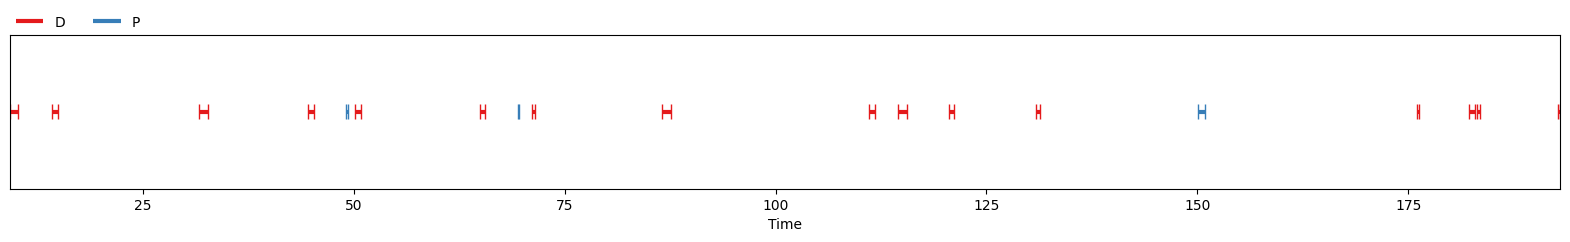

In [11]:
from pyannote.audio.utils.signal import Binarize

# utiliser pour binarizer les prédictions faites par l'inférence (0 = classe inactive, 1 = classe active pour une trame donnée)
binarize = Binarize(onset=0.6, offset=0.5)

test_file = next(protocol.test())

prediction = inference(test_file)
prediction.labels = model.task.prepared_data["metadata-labels"]
binarized_prediction = binarize(prediction)

binarized_prediction

On peut visuellement comparer la prédiction à la référence:

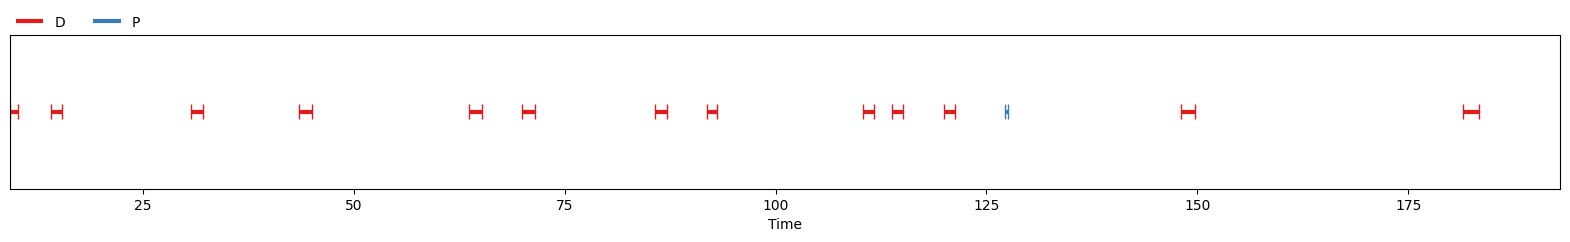

In [13]:
reference = test_file["annotation"]
reference

Visualisation de la waveform du microphone:

(3924669,)


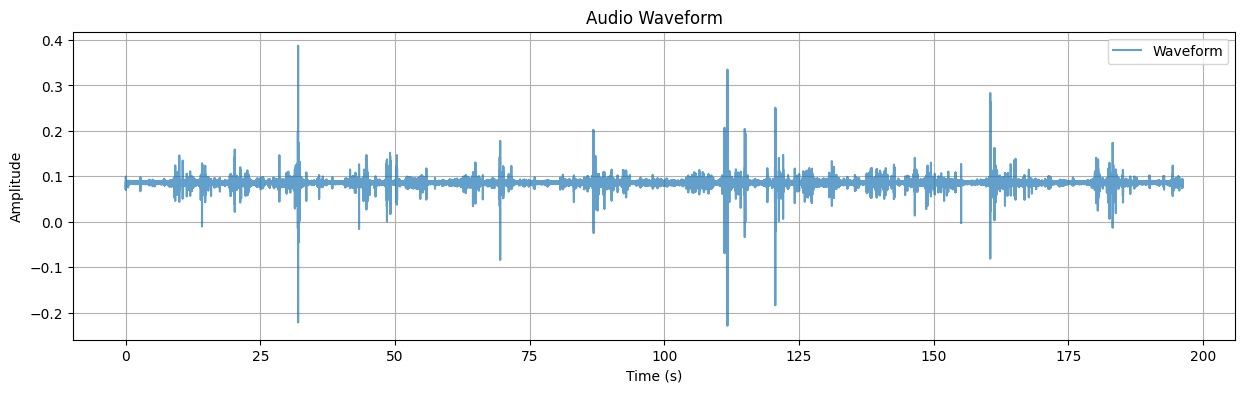

In [12]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load the audio file (Replace with your actual file path)
audio_path = test_file["audio"]
y, sr = librosa.load(audio_path, sr=None, mono=False)  # Load with original sampling rate
y = y[3, :]

# Create a time axis in seconds
time_axis = np.linspace(0, len(y) / sr, len(y))

# Plot the waveform
plt.figure(figsize=(15, 4))
plt.plot(time_axis, y, alpha=0.7, label="Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.legend()
plt.grid()
plt.show()


Pour visualiser la waveform du microphone, il est aussi possible d'utiliser l'outil [`gryannote`](https://github.com/clement-pages/gryannote), qui est initialement dédié à l'annotation d'audios pour la tâche de diarization, mais qui peut également être utilisé pour visualiser des annotations (au format RTTM). Voici ci-après un exemple d'utilisation. Une fois `gryannote` installé (`pip install gryannote`), il est possible d'exécuter cet exemple à l'aide de la commande `gradio nom_du_script.py`

```python
import gradio as gr
# pip install gryannote. Il peut aussi être nécessaire d'installer node.js si celui-ci n'est pas déjà installé.
from gryannote_audio import Player
from pyannote.database.util import load_rttm
import torchaudio

waveform, sample_rate = torchaudio.load("path/to/audio.wav")
audio = waveform.numpy()[-1, :] # gryannote ne gère pas les audios multicanaux

annotations = load_rttm("path/to/rttm.rttm")["REMPLACER PAR L'URI"]

# Lancement de l'interface gradio
demo = gr.Interface(fn=lambda x: x, inputs=[], outputs=[player])

if __name__ == "__main__":
    demo.launch()
````

Evaluons maintenant le modèle sur sa capacité à correctement segmenter les déglutitions. Il faut tout d'abord isoler les déglutitions dans la prédiction et la référence:

In [15]:
from pyannote.core import Annotation, Segment

def filter_annotation(annotation: Annotation, type: str) -> Annotation:
    filtered_annotation = Annotation(uri=annotation.uri)
    for seg, track, label in annotation.itertracks(yield_label=True):
        if label == type:
            filtered_annotation[seg, track] = label
    return filtered_annotation

filtered_pred = filter_annotation(binarized_prediction, type="D")
filtered_ref = filter_annotation(reference, type="D")

On peut ensuite calculer un certain nombre de statistiques pour comparer la sortie du modèle à la référence:

In [16]:
duree_totale_ref = 0
duree_totale_hyp = 0

ref=reference.get_timeline()
hyp=filtered_pred.get_timeline()

# On fusionne les segments qui se chevauchent avec un collar de 0.1 secondes (ie les segments de déglutition distant de moins de 0.1 seconde sont fusionnés)
hyp=hyp.support(collar=0.1)

# Calcul de la duree moyenne des segments à trouver
for segment in ref:
    duree_totale_ref += segment.duration

# Calcul de la durée des segments de déglutition dans l'hypothèse
for segment in hyp:
    duree_totale_hyp += segment.duration

# Calcul des stats sur le fichier en cours
nb_segments_atrouver = len(ref)
print("Nombre à trouver = ",nb_segments_atrouver)

nb_segments_hyp = len(hyp)

print(f"Durée moyenne ref = {duree_totale_ref / nb_segments_atrouver:.3}")
print(f"Durée moyenne hyp = {duree_totale_hyp / nb_segments_hyp:.3}")

# Nombre de segments de déglutition correctement trouvés
nb_hit=0
for segment1,segment2 in ref.co_iter(hyp):
    print(segment1,segment2)
    nb_hit += 1
print("Nombre de HIT    = ",nb_hit," soit ",nb_hit/nb_segments_atrouver*100,"%")

# Nombre de segment manqué par le système
nb_miss=0
for segment in ref:
    if not hyp.crop(segment):
        print(segment)
        nb_miss += 1
print("Nombre de MISS   = ",nb_miss)

# Nombre de segmetn ajouté par le système (mais absent dans la référence)
nb_insert = 0
for segment in hyp:
    if not ref.crop(segment):
        print(segment)
        nb_insert += 1
print("Nombre de INSERT = ",nb_insert)


Nombre à trouver =  14
Durée moyenne ref = 1.35
Durée moyenne hyp = 0.659
[ 00:00:09.190 -->  00:00:10.200] [ 00:00:09.227 -->  00:00:10.139]
[ 00:00:14.080 -->  00:00:15.400] [ 00:00:14.256 -->  00:00:14.931]
[ 00:00:30.670 -->  00:00:32.130] [ 00:00:31.654 -->  00:00:32.650]
[ 00:00:43.530 -->  00:00:45.000] [ 00:00:44.547 -->  00:00:45.272]
[ 00:01:03.680 -->  00:01:05.200] [ 00:01:04.898 -->  00:01:05.505]
[ 00:01:09.910 -->  00:01:11.520] [ 00:01:11.091 -->  00:01:11.530]
[ 00:01:25.750 -->  00:01:27.090] [ 00:01:26.582 -->  00:01:27.629]
[ 00:01:50.350 -->  00:01:51.710] [ 00:01:51.068 -->  00:01:51.827]
[ 00:01:53.770 -->  00:01:55.140] [ 00:01:54.460 -->  00:01:55.523]
[ 00:02:00.020 -->  00:02:01.320] [ 00:02:00.552 -->  00:02:01.142]
[ 00:03:01.440 -->  00:03:03.340] [ 00:03:02.213 -->  00:03:02.972]
[ 00:03:01.440 -->  00:03:03.340] [ 00:03:03.158 -->  00:03:03.462]
Nombre de HIT    =  12  soit  85.71428571428571 %
[ 00:01:31.810 -->  00:01:33.020]
[ 00:02:07.150 -->  00:02:

Il est possible de sauvegarder les annotations produites par le système pour pouvoir les réutiliser plus tard dans un fichier RTTM.

In [17]:
from pathlib import Path

uri = test_file["uri"]
binarized_prediction.uri = uri
rttm_file = Path(f"{uri}.rttm")

with rttm_file.open("w") as rttm_file:
    binarized_prediction.write_rttm(rttm_file)

## Bonus : reprendre un entraînement ou valider un modèle

Avec les dernières modifications apportées à `pyannote` permettant la sauvegarde des paramètres de la tâche dans un checkpoint, il est possible de reprendre très facilement un entraînement à partir de ce checkpoint, en seulement quelques lignes de codes. De la même façon, on peut valider un modèle, en remplaçant `fit` par `validate`

In [ ]:
from pyannote.audio import Model

# /!\ La ligne de code ci-dessous est sujette à modification (suppression de protocol=protocol)
model = Model.from_pretrained("path/to/checkpoint.ckpt", protocol=protocol)

trainer = Trainer(...)
trainer.fit(model) # pour poursuivre l'entraînement du modèle
trainer.validate(model) # pour valider le modèle sur la partition development

Le code ci-dessus n'est valable que sur la branche `phlesnid` de `pyannote`. Sinon, le code à utiliser est le suivant:

In [ ]:
from pyannote.audio import Model
from pyannote.audio.tasks import MultiLabelSegmentation

model = Model.from_pretrained("path/to/checkpoint.ckpt")

task = MultiLabelSegmentation(...)
model.task = task

trainer = Trainer(...)
trainer.fit(model)

Une autre option, est de passer par l'argument `ckpt_path`du `Trainer`:

In [ ]:
from pyannote.audio.models.segmentation import PyanNet
from pyannote.audio.tasks import MultiLabelSegmentation


task = MultiLabelSegmentation(...)
model = PyanNet(task=task, ...)

trainer = Trainer(...)
trainer.fit(model, ckpt_path="path/to/checkpoint.ckpt")
